# Bayesian GPD baseline

This notebook implements the Bayesian baseline for extreme value analysis using the Generalised Pareto Distribution (GPD), against which a possibilistic inference framework will later be compared.

Uninformative prior: Castellanos & Cabras (2007) — $p(\xi, \sigma) \propto \sigma^{-1}(1+\xi)^{-1}(1+2\xi)^{-1/2}$

Outline:
1. Setup & helpers  
2. GPD simulation  
3. Bayesian fitting (MCMC with C&C prior)  
4. Single-fit diagnostics  
5. Monte Carlo experiment (varying $n$, $\xi$)  
6. Accuracy metrics  
7. Uncertainty quantification & calibration  
8. Computational cost  
9. Return-level analysis  
10. Potential extension

## 1. Setup

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
import pandas as pd

import pymc as pm #used for monte carlo simulations, uses pytensor math bc fast
import pytensor.tensor as pt
import arviz as az #exploratory analysis of bayesian models (posterior analysis, model checking, comparison, diagnostic...)
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
COLORS = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']

print('PyMC version:', pm.__version__)
print('ArviZ version:', az.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC version: 6.0.1
ArviZ version: 1.1.0


Comments on the libraries and functions: 

pm.sample() generates an InferenceData object commonly called a "trace" It is a complete historical record of the sampler's journey. Plotting a histogram of the estimates computed at each steps gives the posterior distribution. 

Specifying the number of "chains" for pymc means that we create for example 4 independent walkers from different random locations. IF they end up on the same region, we can be confident. The "tune" parameter is for the burn-in. "draw" is the final number of steps. 

## 2. GPD simulation

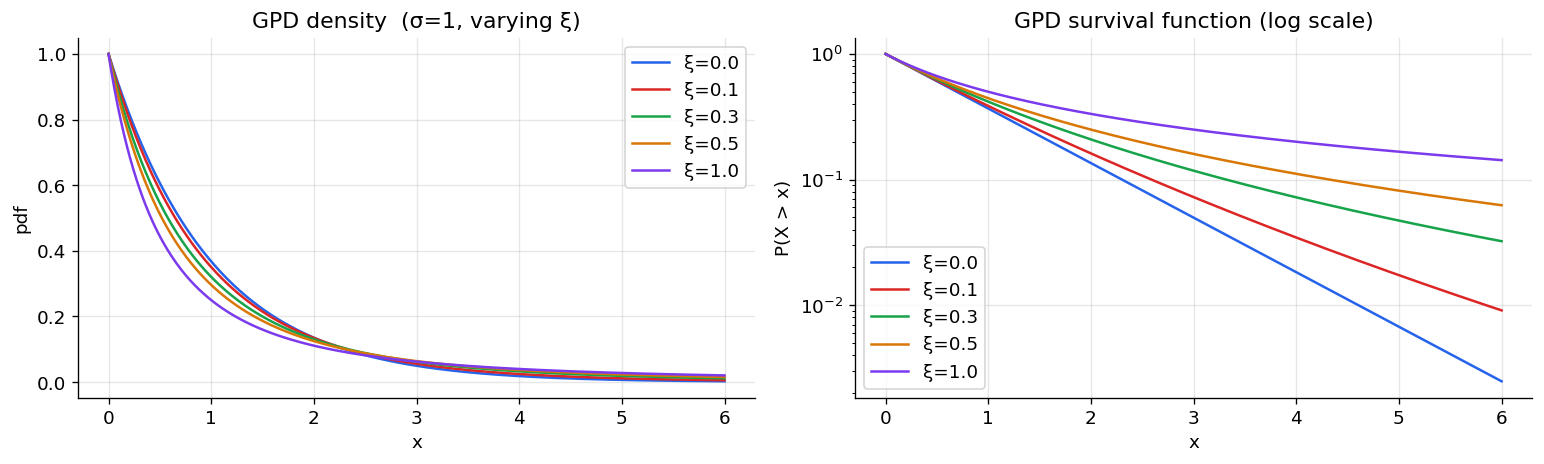

In [ ]:
def simulate_gpd(n: int, xi: float, sigma: float, seed=None) -> np.ndarray:
    """Sample n exceedances from GPD(xi, sigma).
    scipy convention: c = xi (shape), scale = sigma.
    """
    rng = np.random.default_rng(seed)
    return stats.genpareto.rvs(c=xi, scale=sigma, size=n, random_state=rng)


def gpd_logpdf(x: np.ndarray, xi: float, sigma: float) -> np.ndarray:
    """Log-pdf of GPD — numerically stable for xi close to 0."""
    return stats.genpareto.logpdf(x, c=xi, scale=sigma)



fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_grid = np.linspace(0, 6, 400)
for i, xi in enumerate([0.0, 0.1, 0.3, 0.5, 1.0]):
    pdf = stats.genpareto.pdf(x_grid, c=xi, scale=1.0)
    axes[0].plot(x_grid, pdf, label=f'ξ={xi}', color=COLORS[i % len(COLORS)])
axes[0].set_title('GPD density  (σ=1, varying ξ)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('pdf')
axes[0].legend()

for i, xi in enumerate([0.0, 0.1, 0.3, 0.5, 1.0]):
    sf = stats.genpareto.sf(x_grid, c=xi, scale=1.0)
    axes[1].semilogy(x_grid, sf, label=f'ξ={xi}', color=COLORS[i % len(COLORS)])
axes[1].set_title('GPD survival function (log scale)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('P(X > x)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Bayesian fitting with Castellanos & Cabras (2007) uninformative prior

The prior is:
$$p(\xi, \sigma) \propto \sigma^{-1}(1+\xi)^{-1}(1+2\xi)^{-1/2}, \quad \xi > -0.5,\ \sigma > 0$$

PyMC has no built-in GPD likelihood, so we implement both the likelihood and the log-prior as `pm.Potential`.

In [ ]:
# TODO: REVERIF SI LES MATHS SONT CORRECTES !!!!!

def cc_logprior(xi, sigma):
    """Log of Castellanos & Cabras (2007) uninformative prior.
    Valid for xi > -0.5, sigma > 0.
    """
    return -pt.log(sigma) - pt.log(1.0 + xi) - 0.5 * pt.log(1.0 + 2.0 * xi)


def gpd_loglik_tensor(x, xi, sigma):
    """Log-likelihood of GPD for a data vector x (PyTensor ops).
    Returns -inf when any observation violates the support.
    GPD support: x >= 0 when xi >= 0, and 0 <= x <= -sigma/xi when xi < 0.
    """
    n = x.shape[0]
    # standardised exceedances
    t = x / sigma

    # log-likelihood body: -n*log(sigma) - (1 + 1/xi)*sum(log(1 + xi*t)) #TODO: revoir le signe!!
    # For xi != 0: log p = -log(sigma) - (1 + 1/xi)*log(1 + xi*t)
    # For xi -> 0: reduces to exponential, log p = -log(sigma) - t
    log_term = pt.log1p(xi * t)            # log(1 + xi * x/sigma)
    ll = -n * pt.log(sigma) - (1.0 + 1.0 / xi) * pt.sum(log_term)
    return ll


def fit_bayesian_gpd(data: np.ndarray,
                     draws: int = 2000,
                     tune: int = 1000,
                     chains: int = 2,
                     target_accept: float = 0.9,
                     progressbar: bool = True):
    """MCMC sampling for the Bayesian GPD model.

    Parameters
    ----------
    data : observed exceedances (positive reals)
    draws, tune, chains : MCMC settings
    target_accept : NUTS acceptance rate target (higher → smaller step size)

    Returns
    -------
    trace : ArviZ InferenceData object
    """
    x = data.astype(float)

    with pm.Model() as model: #creation of a Bayesian model
        # ── priors: we sample on an unconstrained scale and then transform ──
        # xi > -0.5  →  reparametrise as xi = -0.5 + exp(xi_raw)
        # sigma > 0  →  sigma = exp(log_sigma)
        xi_raw    = pm.Flat('xi_raw')            # unconstrained
        log_sigma = pm.Flat('log_sigma')         # unconstrained
        # flat means we have no idea what the value of the parameters are when considering their priors

        xi    = pm.Deterministic('xi',    -0.5 + pt.exp(xi_raw))
        sigma = pm.Deterministic('sigma', pt.exp(log_sigma))
        # deterministic is to calculate the value directly, no sampling. 

        # ── Castellanos & Cabras log-prior ───────────────────────────────────
        # Jacobian of the transformation: d(xi)/d(xi_raw) = exp(xi_raw) = xi + 0.5
        #                                 d(sigma)/d(log_sigma) = sigma
        lp_prior = cc_logprior(xi, sigma)
        lp_jacobian = xi_raw + log_sigma        # log|det J|
        pm.Potential('prior', lp_prior + lp_jacobian)
        # potential is to add a customized function, the log prior, we sum the log Jacobian bc we used a change of variable (??)

        # ── GPD log-likelihood ───────────────────────────────────────────────
        # Guard: 1 + xi*(x/sigma) must be > 0 for all observations
        t = pt.as_tensor_variable(x) / sigma
        valid = pt.all(1.0 + xi * t > 0)
        log_term = pt.log1p(xi * t)
        ll = -x.size * pt.log(sigma) - (1.0 + 1.0 / xi) * pt.sum(log_term)
        pm.Potential('likelihood', pt.switch(valid, ll, -pt.inf))

        # ── NUTS sampling ────────────────────────────────────────────────────
        # no u turn sampling
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            progressbar=progressbar,
            return_inferencedata=True,
        )

        map_estimate = pm.find_MAP()
        print(f"MAP estimate: xi={map_estimate["xi"]}, sigma={map_estimate["sigma"]}")

    return trace


print('Model definition: OK')

Model definition: OK


## 4. Single-fit diagnostics

Fit on one synthetic dataset and inspect the posterior thoroughly.

In [25]:
XI_TRUE    = 0.3
SIGMA_TRUE = 1.0
N_DEMO     = 500

data_demo = simulate_gpd(N_DEMO, xi=XI_TRUE, sigma=SIGMA_TRUE, seed=0)

print(f'Simulated {N_DEMO} exceedances: mean={data_demo.mean():.3f}, '
      f'max={data_demo.max():.3f}')

t0 = time.time()
trace_demo = fit_bayesian_gpd(data_demo, draws=3000, tune=1500, chains=4)
t_demo = time.time() - t0
print(f'\nSampling time: {t_demo:.1f}s')

Initializing NUTS using jitter+adapt_diag...


Simulated 500 exceedances: mean=1.582, max=16.129


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [xi_raw, log_sigma]


Output()

Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 15 seconds.


Output()

MAP estimate: xi=0.5, sigma=1.0

Sampling time: 22.1s


In [26]:
# ── MCMC convergence diagnostics ─────────────────────────────────────────────
summary = az.summary(trace_demo, var_names=['xi', 'sigma'], round_to=4)
print(summary)
print(f'\nTrue values:  xi={XI_TRUE}, sigma={SIGMA_TRUE}')

         mean      sd  eti89_lb  eti89_ub   ess_bulk   ess_tail   r_hat  \
xi     0.2687  0.0579    0.1792    0.3647  3856.4622  5343.4761  1.0008   
sigma  1.1732  0.0843    1.0432    1.3116  4301.4966  5580.9835  1.0010   

       mcse_mean  mcse_sd  
xi        0.0009   0.0007  
sigma     0.0013   0.0009  

True values:  xi=0.3, sigma=1.0


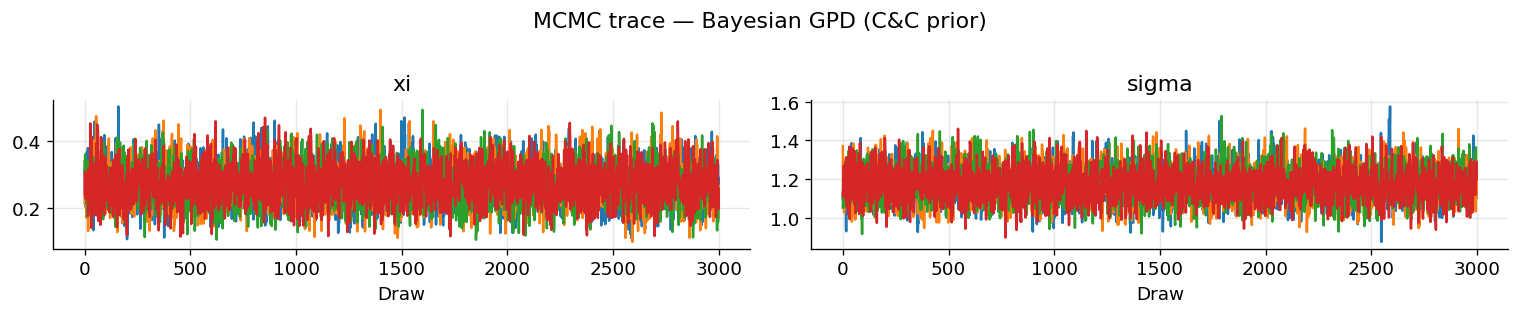

In [27]:
# ── Trace plots ──────────────────────────────────────────────────────────────
az.plot_trace(trace_demo, var_names=['xi', 'sigma'])
plt.suptitle('MCMC trace — Bayesian GPD (C&C prior)', y=1.01)
plt.tight_layout()
plt.show()
# these are the curves from the walkers, if it looks like white noise, no difference between the walkers: it's good. 

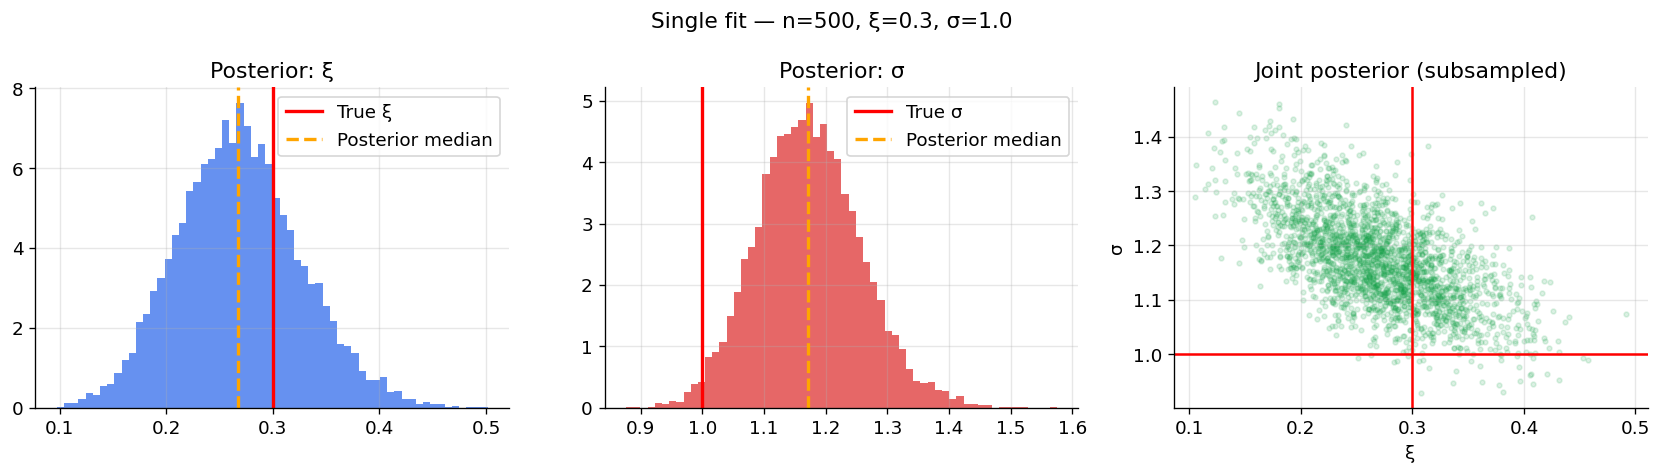

In [28]:
# ── Posterior marginals with true values ─────────────────────────────────────
xi_post    = trace_demo.posterior['xi'].values.flatten()
sigma_post = trace_demo.posterior['sigma'].values.flatten()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(xi_post, bins=60, density=True, color=COLORS[0], alpha=0.7)
axes[0].axvline(XI_TRUE, color='red', lw=2, label='True ξ')
axes[0].axvline(np.median(xi_post), color='orange', lw=2, ls='--', label='Posterior median')
axes[0].set_title('Posterior: ξ'); axes[0].legend()

axes[1].hist(sigma_post, bins=60, density=True, color=COLORS[1], alpha=0.7)
axes[1].axvline(SIGMA_TRUE, color='red', lw=2, label='True σ')
axes[1].axvline(np.median(sigma_post), color='orange', lw=2, ls='--', label='Posterior median')
axes[1].set_title('Posterior: σ'); axes[1].legend()

axes[2].scatter(xi_post[::5], sigma_post[::5], alpha=0.15, s=8, color=COLORS[2])
axes[2].axvline(XI_TRUE, color='red', lw=1.5); axes[2].axhline(SIGMA_TRUE, color='red', lw=1.5)
axes[2].set_xlabel('ξ'); axes[2].set_ylabel('σ')
axes[2].set_title('Joint posterior (subsampled)')

plt.suptitle(f'Single fit — n={N_DEMO}, ξ={XI_TRUE}, σ={SIGMA_TRUE}', fontsize=13)
plt.tight_layout()
plt.show()

## TEST with possibility


In [12]:
def gpd_loglik(params, x):
    """Log-likelihood of the GPD (sum of log-densities), -inf outside support."""
    xi, sigma = params
    if sigma <= 0:
        return -np.inf
    if np.any(1.0 + xi * x / sigma <= 0):     # GPD support condition
        return -np.inf
    return np.sum(stats.genpareto.logpdf(x, c=xi, scale=sigma))


def box_prior(xi, sigma, xi_bounds=(0.0, 3.0), sigma_bounds=(0.0, 2.0)):
    """Possibilistic prior: f = 1 on the box, 0 outside. No normalisation needed."""
    in_box = (xi_bounds[0] <= xi <= xi_bounds[1]) and (sigma_bounds[0] <= sigma <= sigma_bounds[1])
    return 1.0 if in_box else 0.0


def possibility_posterior(xi, sigma, data, max_loglik,
                           xi_bounds=(0.0, 3.0), sigma_bounds=(0.0, 2.0)):
    """f(xi, sigma | x) = L(xi,sigma|x) / max_box L(.|x), restricted to the prior box."""
    if box_prior(xi, sigma, xi_bounds, sigma_bounds) == 0.0:
        return 0.0
    ll = gpd_loglik((xi, sigma), data)
    return float(np.exp(ll - max_loglik)) if np.isfinite(ll) else 0.0

In [ ]:
from scipy.optimize import minimize

def fit_possibilistic_gpd(data, xi_bounds=(0.0, 3.0), sigma_bounds=(0.0, 2.0), n_starts=8, seed=0):
    """Possibilistic MAP estimator for the GPD: constrained MLE over the prior box.

    Returns the MAP, the normalising max log-likelihood (the 'evidence' analogue),
    and the observed information / covariance, computed exactly as in the document:
        V*(theta|x)^{-1} = -H_theta( log p(x|theta_hat) )
    i.e. minus the Hessian of the LOG-LIKELIHOOD (not log-posterior) at the MAP,
    since the indicator prior contributes zero curvature inside the box.
    """
    x = np.asarray(data, dtype=float)

    def neg_ll(params):
        ll = gpd_loglik(params, x)
        return -ll if np.isfinite(ll) else 1e10

    rng = np.random.default_rng(seed)
    starts = [(0.1, x.mean())] + [
        (rng.uniform(*xi_bounds), rng.uniform(max(sigma_bounds[0], 1e-3), sigma_bounds[1]))
        for _ in range(n_starts)
    ]

    best = None
    for x0 in starts:
        res = minimize(neg_ll, x0=x0, method='L-BFGS-B',
                        bounds=[xi_bounds, (max(sigma_bounds[0], 1e-6), sigma_bounds[1])])
        if best is None or res.fun < best.fun:
            best = res

    xi_map, sigma_map = best.x
    max_loglik = -best.fun  # = log( max_box L(.|x) ), the Bayes-rule normaliser

    # observed information = -Hessian of the log-likelihood at the MAP (finite differences)
    theta0, eps = np.array([xi_map, sigma_map]), 1e-4
    H = np.zeros((2, 2))
    for i in range(2):
        for j in range(2):
            p1, p2, p3, p4 = (theta0.copy() for _ in range(4))
            p1[i] += eps; p1[j] += eps
            p2[i] += eps; p2[j] -= eps
            p3[i] -= eps; p3[j] += eps
            p4[i] -= eps; p4[j] -= eps
            H[i, j] = (gpd_loglik(p1, x) - gpd_loglik(p2, x)
                       - gpd_loglik(p3, x) + gpd_loglik(p4, x)) / (4 * eps**2)

    info = -H
    cov = np.linalg.inv(info)

    return {
        'xi_map': xi_map, 'sigma_map': sigma_map,
        'max_loglik': max_loglik, 'cov': cov, 'info': info,
        'xi_bounds': xi_bounds, 'sigma_bounds': sigma_bounds,
    }


print('ok')

Model definition: OK (no MCMC required)


In [17]:
t0 = time.time()
poss_fit = fit_possibilistic_gpd(data_demo)
t_poss = time.time() - t0

sd = np.sqrt(np.diag(poss_fit['cov']))
print(f"Possibilistic MAP:  xi={poss_fit['xi_map']:.4f}  sigma={poss_fit['sigma_map']:.4f}")
print(f"Approx. plausibility sd (from observed info):  xi_sd={sd[0]:.4f}  sigma_sd={sd[1]:.4f}")
print(f"True values:  xi={XI_TRUE}, sigma={SIGMA_TRUE}")
print(f"\nFitting time: {t_poss*1000:.1f} ms   (Bayesian MCMC took {t_demo:.1f} s)")

Possibilistic MAP:  xi=0.2993  sigma=1.2271
Approx. plausibility sd (from observed info):  xi_sd=0.0991  sigma_sd=0.1472
True values:  xi=0.3, sigma=1.0

Fitting time: 192.1 ms   (Bayesian MCMC took 30.5 s)


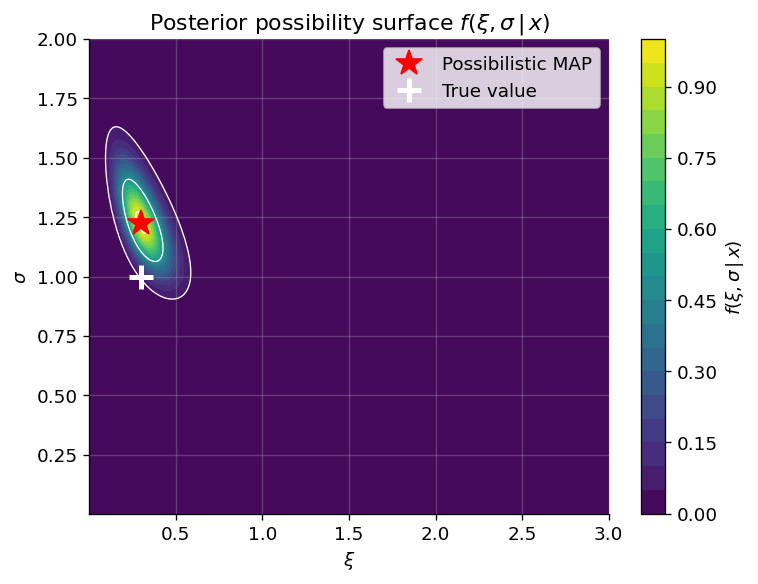

In [18]:
xi_grid = np.linspace(poss_fit['xi_bounds'][0] + 1e-3, poss_fit['xi_bounds'][1], 200)
sigma_grid = np.linspace(poss_fit['sigma_bounds'][0] + 1e-3, poss_fit['sigma_bounds'][1], 200)
XI, SIGMA = np.meshgrid(xi_grid, sigma_grid)

F = np.vectorize(lambda xi, sigma: possibility_posterior(xi, sigma, data_demo, poss_fit['max_loglik']))(XI, SIGMA)

fig, ax = plt.subplots(figsize=(6.5, 5))
cf = ax.contourf(XI, SIGMA, F, levels=20, cmap='viridis')
ax.contour(XI, SIGMA, F, levels=[0.05, 0.5, 0.95], colors='white', linewidths=0.8)  # alpha-cuts
plt.colorbar(cf, label=r'$f(\xi,\sigma\,|\,x)$')
ax.plot(poss_fit['xi_map'], poss_fit['sigma_map'], 'r*', ms=16, label='Possibilistic MAP')
ax.plot(XI_TRUE, SIGMA_TRUE, 'w+', ms=14, mew=3, label='True value')
ax.set_xlabel(r'$\xi$'); ax.set_ylabel(r'$\sigma$')
ax.set_title('Posterior possibility surface $f(\\xi,\\sigma\\,|\\,x)$')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

going back to bayesian

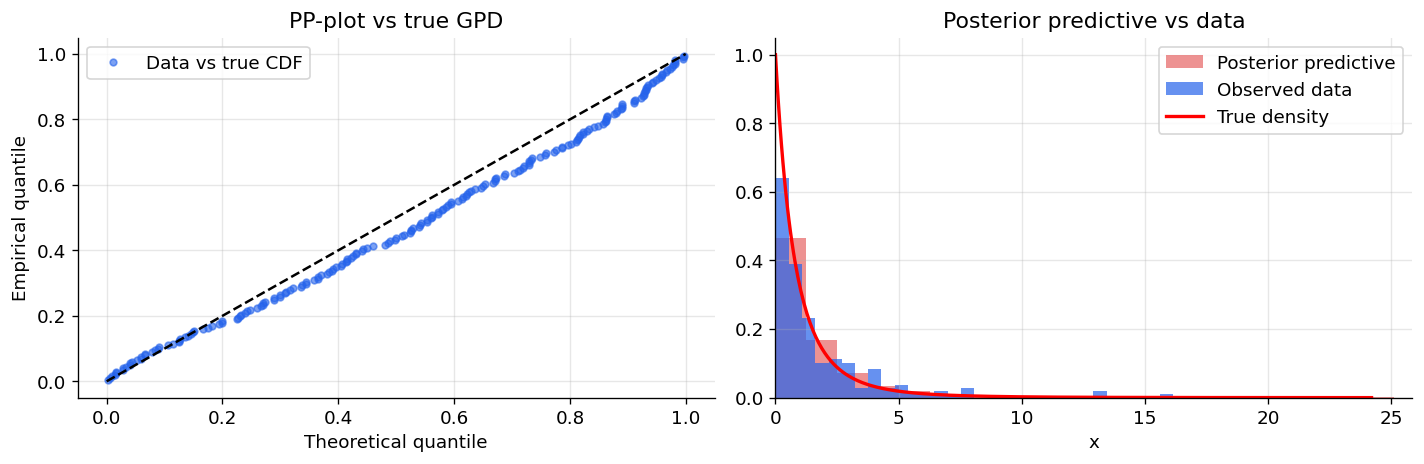

In [8]:
# ── Posterior predictive samples & empirical CDF check ───────────────────────
def posterior_predictive_samples(trace, n_pred: int = 5000, rng=None) -> np.ndarray:
    """Draw from the posterior predictive by mixing over posterior parameter samples."""
    rng = np.random.default_rng(rng)
    xi_s    = trace.posterior['xi'].values.flatten()
    sigma_s = trace.posterior['sigma'].values.flatten()
    idx = rng.integers(0, len(xi_s), size=n_pred)
    return stats.genpareto.rvs(
        c=xi_s[idx], scale=sigma_s[idx], random_state=rng)


pp_samples = posterior_predictive_samples(trace_demo, n_pred=10000)

# QQ-plot: posterior predictive vs data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# empirical vs theoretical CDF at true params
x_sorted = np.sort(data_demo)
p_emp    = np.arange(1, N_DEMO + 1) / (N_DEMO + 1)
p_theor  = stats.genpareto.cdf(x_sorted, c=XI_TRUE, scale=SIGMA_TRUE)

axes[0].plot(p_theor, p_emp, 'o', ms=4, color=COLORS[0], alpha=0.6, label='Data vs true CDF')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_xlabel('Theoretical quantile'); axes[0].set_ylabel('Empirical quantile')
axes[0].set_title('PP-plot vs true GPD')
axes[0].legend()

# compare posterior predictive histogram vs data
axes[1].hist(pp_samples, bins=80, density=True, alpha=0.5, color=COLORS[1], label='Posterior predictive')
axes[1].hist(data_demo,  bins=30, density=True, alpha=0.7, color=COLORS[0], label='Observed data')
xg = np.linspace(0, data_demo.max() * 1.5, 400)
axes[1].plot(xg, stats.genpareto.pdf(xg, c=XI_TRUE, scale=SIGMA_TRUE),
             'r-', lw=2, label='True density')
axes[1].set_xlim(0, np.percentile(data_demo, 99) * 2)
axes[1].set_xlabel('x'); axes[1].set_title('Posterior predictive vs data')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Monte Carlo experiment

Repeat across sample sizes $n \in \{20, 50, 100, 500\}$ and shape parameters $\xi \in \{0.1, 0.3, 0.5\}$.

In [9]:
# ─── helper functions ────────────────────────────────────────────────────────

def true_quantile(p: float, xi: float, sigma: float) -> float:
    """Exact GPD quantile at level p."""
    return float(stats.genpareto.ppf(p, c=xi, scale=sigma))


def return_level(xi: np.ndarray, sigma: np.ndarray, T: float) -> np.ndarray:
    """Return level for return period T (exceedance prob 1/T).
    x_T = sigma/xi * (T^xi - 1)  for xi != 0
        = sigma * log(T)          for xi == 0  (limit)
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.where(
            np.abs(xi) < 1e-8,
            sigma * np.log(T),
            sigma / xi * (T ** xi - 1.0)
        )
    return out


def coverage_check(true_val: float, samples: np.ndarray,
                   alpha: float = 0.95) -> bool:
    """True iff true_val lies inside the (1-alpha)/2 central credible interval."""
    lo = np.quantile(samples, (1.0 - alpha) / 2.0)
    hi = np.quantile(samples, 1.0 - (1.0 - alpha) / 2.0)
    return bool(lo <= true_val <= hi)


def interval_width(samples: np.ndarray, alpha: float = 0.95) -> float:
    lo = np.quantile(samples, (1.0 - alpha) / 2.0)
    hi = np.quantile(samples, 1.0 - (1.0 - alpha) / 2.0)
    return float(hi - lo)


print('Helpers: OK')

Helpers: OK


In [10]:
def run_experiment(n: int, xi_true: float, sigma_true: float,
                   p: float = 0.99, T: float = 100.0,
                   draws: int = 1500, tune: int = 800,
                   seed: int = None) -> dict:
    """
    Full pipeline: simulate → fit → evaluate.

    Returns a dict with accuracy, calibration, and timing metrics.
    """
    rng = np.random.default_rng(seed)
    data = simulate_gpd(n, xi_true, sigma_true, seed=int(rng.integers(1e9)))

    # ── fit ──────────────────────────────────────────────────────────────────
    t_start = time.time()
    trace   = fit_bayesian_gpd(data, draws=draws, tune=tune,
                               chains=2, progressbar=False)
    runtime = time.time() - t_start

    xi_s    = trace.posterior['xi'].values.flatten()
    sigma_s = trace.posterior['sigma'].values.flatten()

    # ── posterior predictive samples ─────────────────────────────────────────
    pred_s = posterior_predictive_samples(trace, n_pred=5000, rng=rng)

    # ── quantile accuracy ────────────────────────────────────────────────────
    q_true = true_quantile(p, xi_true, sigma_true)
    q_est  = float(np.quantile(pred_s, p))          # posterior predictive quantile

    # ── return level ─────────────────────────────────────────────────────────
    rl_samples = return_level(xi_s, sigma_s, T)
    rl_true    = return_level(np.array([xi_true]), np.array([sigma_true]), T)[0]

    # ── MCMC diagnostics ─────────────────────────────────────────────────────
    rhat_xi    = float(az.rhat(trace, var_names=['xi'])['xi'].values)
    rhat_sigma = float(az.rhat(trace, var_names=['sigma'])['sigma'].values)
    ess_xi     = float(az.ess(trace, var_names=['xi'])['xi'].values)

    return {
        'n':              n,
        'xi_true':        xi_true,
        'sigma_true':     sigma_true,
        # --- parameter accuracy ---
        'xi_bias':        float(np.median(xi_s))    - xi_true,
        'xi_rmse':        float(np.sqrt(np.mean((xi_s - xi_true)**2))),
        'sigma_bias':     float(np.median(sigma_s)) - sigma_true,
        'sigma_rmse':     float(np.sqrt(np.mean((sigma_s - sigma_true)**2))),
        # --- quantile accuracy ---
        'q_true':         q_true,
        'q_est':          q_est,
        'q_abs_error':    abs(q_est - q_true),
        'q_rel_error':    abs(q_est - q_true) / (abs(q_true) + 1e-12),
        'q_covered_95':   coverage_check(q_true, pred_s, alpha=0.95),
        'q_covered_50':   coverage_check(q_true, pred_s, alpha=0.50),
        'q_width_95':     interval_width(pred_s, alpha=0.95),
        # --- return level accuracy ---
        'rl_true':        rl_true,
        'rl_est':         float(np.median(rl_samples)),
        'rl_abs_error':   abs(float(np.median(rl_samples)) - rl_true),
        'rl_covered_95':  coverage_check(rl_true, rl_samples, alpha=0.95),
        'rl_width_95':    interval_width(rl_samples, alpha=0.95),
        # --- MCMC quality ---
        'rhat_xi':        rhat_xi,
        'rhat_sigma':     rhat_sigma,
        'ess_xi':         ess_xi,
        # --- timing ---
        'runtime_s':      runtime,
    }


print('run_experiment: OK')

run_experiment: OK


In [11]:
# ── experiment grid ───────────────────────────────────────────────────────────
# To run the full grid, set N_REPS = 20 and uncomment all n / xi values.
# For a quick test, use N_REPS = 5.

N_REPS     = 5
NS         = [20, 50, 100, 500]
XI_VALUES  = [0.1, 0.3, 0.5]
SIGMA_TRUE = 1.0

results = []
master_seed = np.random.SeedSequence(42)
seeds = master_seed.spawn(N_REPS * len(NS) * len(XI_VALUES))

job_idx = 0
for n in NS:
    for xi_true in XI_VALUES:
        for rep in tqdm(range(N_REPS),
                        desc=f'n={n}, ξ={xi_true}', leave=False):
            seed = seeds[job_idx].generate_state(1)[0]
            job_idx += 1
            try:
                res = run_experiment(n, xi_true, SIGMA_TRUE, seed=int(seed))
                res['rep'] = rep
                results.append(res)
            except Exception as e:
                print(f'  FAILED n={n} xi={xi_true} rep={rep}: {e}')

df = pd.DataFrame(results)
print(f'\nTotal successful runs: {len(df)}')
df.head(3)

n=20, ξ=0.1:   0%|          | 0/5 [00:00<?, ?it/s]Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [xi_raw, log_sigma]
Sampling 2 chains for 800 tune and 1_500 draw iterations (1_600 + 3_000 draws total) took 8 seconds.
There were 248 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Output()

n=20, ξ=0.1:  20%|██        | 1/5 [00:13<00:53, 13.26s/it]

MAP estimate: xi=-0.1643107859469789, sigma=1.4432754178321765


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [xi_raw, log_sigma]
Sampling 2 chains for 800 tune and 1_500 draw iterations (1_600 + 3_000 draws total) took 7 seconds.
There were 61 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Output()

n=500, ξ=0.3:  60%|██████    | 3/5 [00:33<00:22, 11.06s/it]Initializing NUTS using jitter+adapt_diag...


MAP estimate: xi=0.5, sigma=1.0


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [xi_raw, log_sigma]


KeyboardInterrupt: 

## 6. Accuracy metrics

In [ ]:
# ── Aggregate summary table ───────────────────────────────────────────────────
agg = df.groupby(['n', 'xi_true']).agg(
    xi_bias_mean    = ('xi_bias',       'mean'),
    xi_rmse_mean    = ('xi_rmse',       'mean'),
    sigma_bias_mean = ('sigma_bias',    'mean'),
    q_abs_error_med = ('q_abs_error',   'median'),
    q_rel_error_med = ('q_rel_error',   'median'),
    rl_abs_error_med= ('rl_abs_error',  'median'),
    coverage_95     = ('q_covered_95',  'mean'),
    coverage_50     = ('q_covered_50',  'mean'),
    width_95_med    = ('q_width_95',    'median'),
    runtime_mean    = ('runtime_s',     'mean'),
).reset_index()

pd.set_option('display.float_format', '{:.4f}'.format)
print(agg.to_string(index=False))

  n  xi_true  xi_bias_mean  xi_rmse_mean  sigma_bias_mean  q_abs_error_med  q_rel_error_med  rl_abs_error_med  coverage_95  coverage_50  width_95_med  runtime_mean
 20   0.1000       -0.2533        0.3788           0.4733           1.7368           0.2969            1.4517       0.3000       0.0000        4.7341       10.9709
 20   0.3000       -0.0656        0.5429           0.2367           5.4745           0.5509            5.5492       0.4000       0.0000        7.2885        9.7679
 20   0.5000       -0.1086        0.5348           0.3172          20.4661           1.1370           12.4779       0.4000       0.0000       16.7355        9.0347
 50   0.1000       -0.0231        0.2256           0.0606           0.3681           0.0629            0.6730       0.0000       0.0000        4.5864        9.5557
 50   0.3000        0.0086        0.2465           0.0766           2.7822           0.2800            2.1637       0.2000       0.0000        7.3677        9.5578
 50   0.5000    

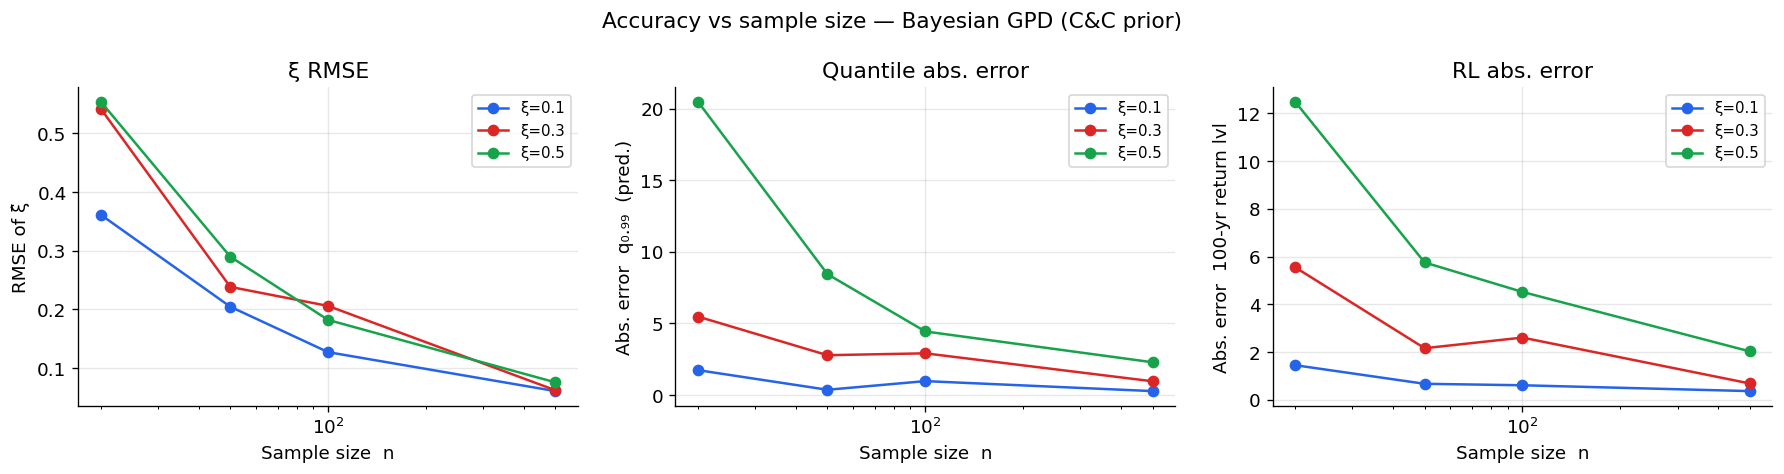

In [ ]:
# ── Plot 1: RMSE of ξ vs sample size, by ξ_true ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

metrics = [
    ('xi_rmse',      'RMSE of ξ̂',                   'ξ RMSE'),
    ('q_abs_error',  'Abs. error  q₀.₉₉  (pred.)',   'Quantile abs. error'),
    ('rl_abs_error', 'Abs. error  100-yr return lvl', 'RL abs. error'),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    for i, xi in enumerate(XI_VALUES):
        sub = df[df['xi_true'] == xi].groupby('n')[col].median()
        ax.plot(sub.index, sub.values, 'o-', color=COLORS[i], label=f'ξ={xi}')
    ax.set_xscale('log')
    ax.set_xlabel('Sample size  n')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Accuracy vs sample size — Bayesian GPD (C&C prior)', fontsize=13)
plt.tight_layout()
plt.show()

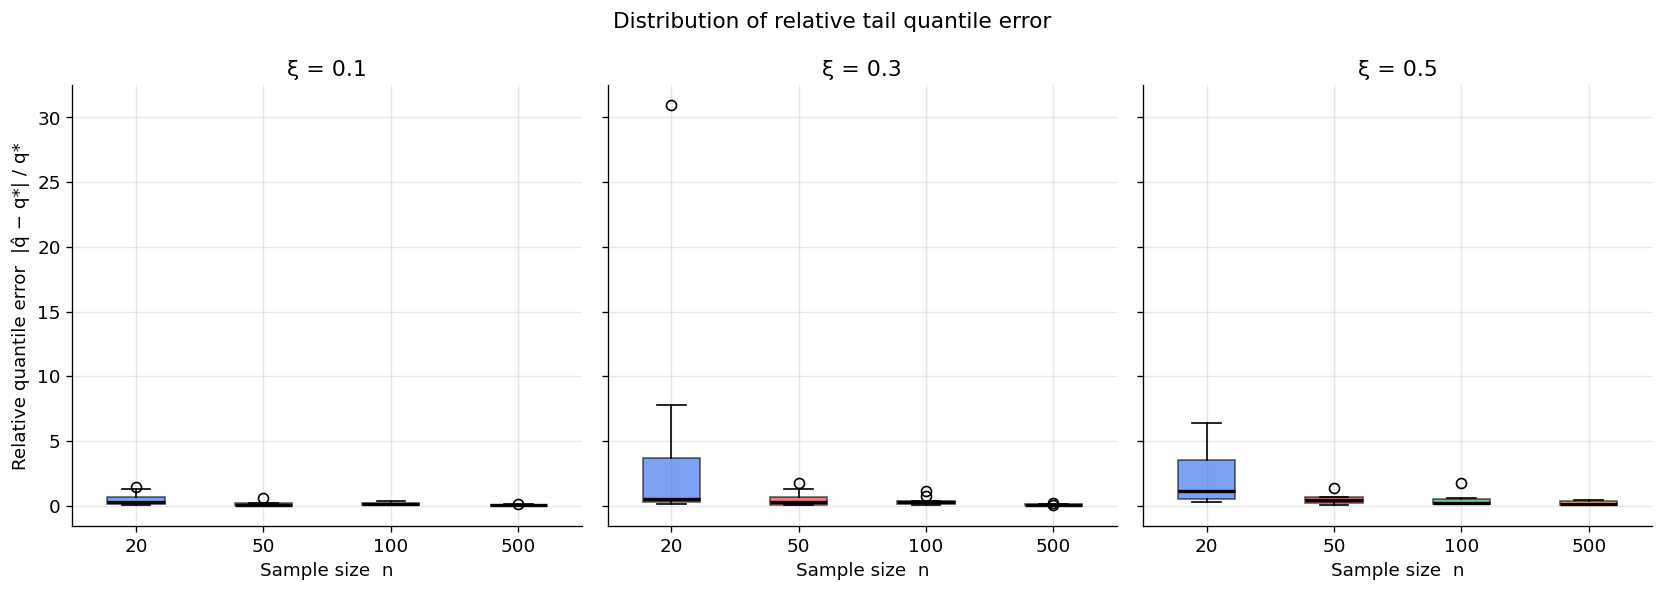

In [ ]:
# ── Plot 2: Relative quantile error as box plots ──────────────────────────────
fig, axes = plt.subplots(1, len(XI_VALUES), figsize=(14, 5), sharey=True)

for ax, xi in zip(axes, XI_VALUES):
    sub   = df[df['xi_true'] == xi]
    groups = [sub[sub['n'] == n]['q_rel_error'].values for n in NS]
    bp = ax.boxplot(groups, labels=[str(n) for n in NS],
                    patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f'ξ = {xi}')
    ax.set_xlabel('Sample size  n')

axes[0].set_ylabel('Relative quantile error  |q̂ − q*| / q*')
plt.suptitle('Distribution of relative tail quantile error', fontsize=13)
plt.tight_layout()
plt.show()

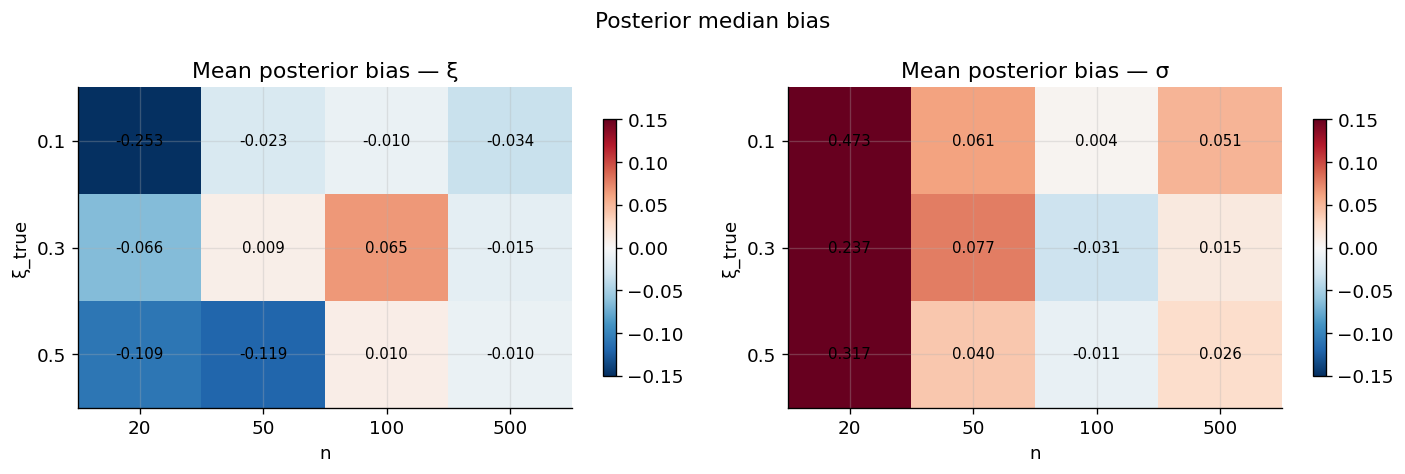

In [ ]:
# ── Plot 3: Parameter bias heat-map ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
        axes,
        ['xi_bias_mean', 'sigma_bias_mean'],
        ['Mean posterior bias — ξ', 'Mean posterior bias — σ']):
    pivot = agg.pivot(index='xi_true', columns='n', values=col)
    im = ax.imshow(pivot.values, aspect='auto',
                   cmap='RdBu_r', vmin=-0.15, vmax=0.15)
    ax.set_xticks(range(len(NS)));    ax.set_xticklabels(NS)
    ax.set_yticks(range(len(XI_VALUES))); ax.set_yticklabels(XI_VALUES)
    ax.set_xlabel('n'); ax.set_ylabel('ξ_true')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for r in range(len(XI_VALUES)):
        for c in range(len(NS)):
            ax.text(c, r, f'{pivot.values[r, c]:.3f}',
                    ha='center', va='center', fontsize=9)

plt.suptitle('Posterior median bias', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Uncertainty quantification & calibration

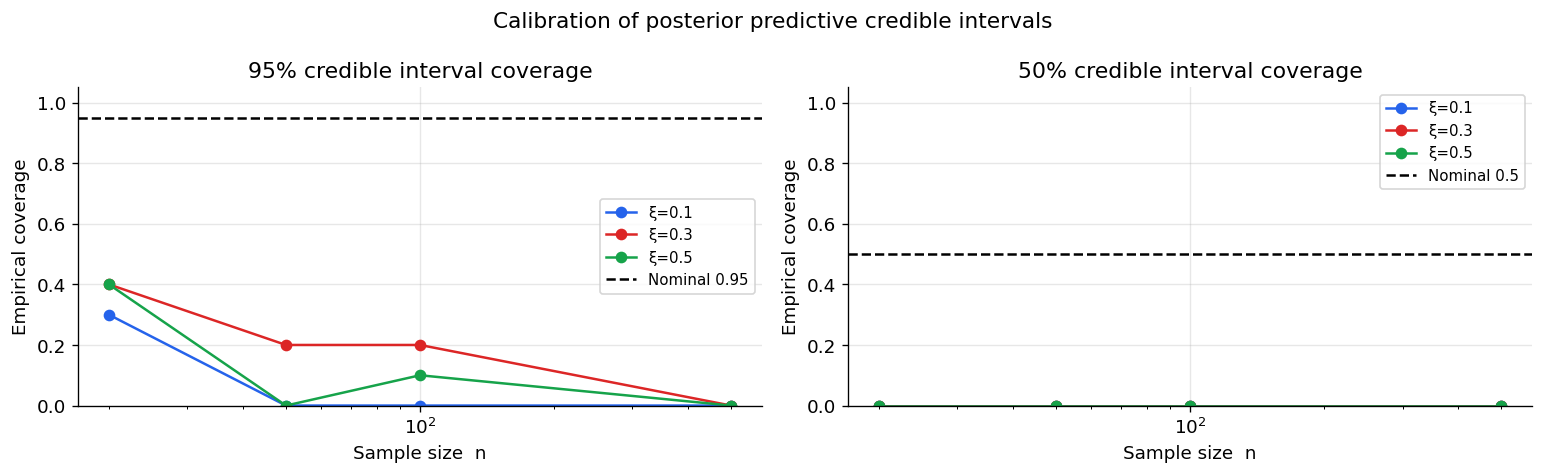

In [ ]:
# ── Plot 4: Coverage rates at 95% and 50% ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, col, nominal, title in zip(
        axes,
        ['q_covered_95', 'q_covered_50'],
        [0.95, 0.50],
        ['95% credible interval coverage', '50% credible interval coverage']):
    for i, xi in enumerate(XI_VALUES):
        sub = df[df['xi_true'] == xi].groupby('n')[col].mean()
        ax.plot(sub.index, sub.values, 'o-', color=COLORS[i], label=f'ξ={xi}')
    ax.axhline(nominal, color='black', ls='--', lw=1.5, label=f'Nominal {nominal}')
    ax.set_xscale('log')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Sample size  n')
    ax.set_ylabel('Empirical coverage')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Calibration of posterior predictive credible intervals', fontsize=13)
plt.tight_layout()
plt.show()

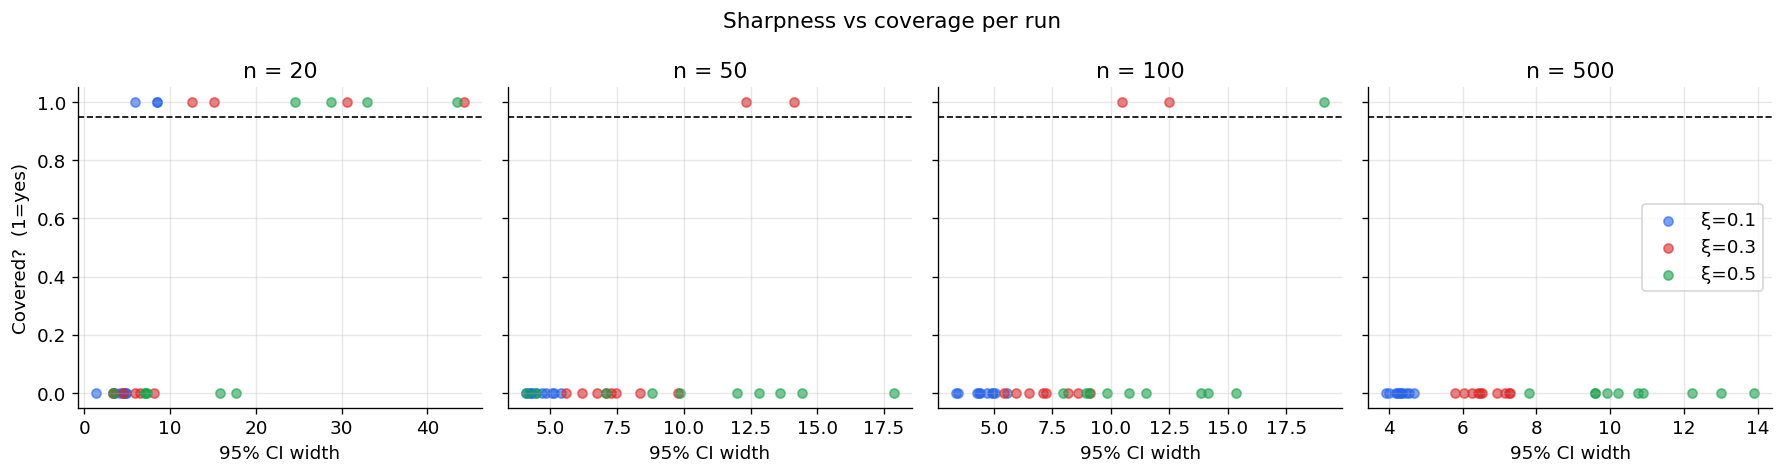

In [ ]:
# ── Plot 5: Interval width vs coverage (sharpness–calibration trade-off) ──────
fig, axes = plt.subplots(1, len(NS), figsize=(15, 4), sharey=True)

for ax, n in zip(axes, NS):
    sub = df[df['n'] == n]
    for i, xi in enumerate(XI_VALUES):
        s = sub[sub['xi_true'] == xi]
        ax.scatter(s['q_width_95'], s['q_covered_95'].astype(float),
                   color=COLORS[i], alpha=0.6, s=30, label=f'ξ={xi}')
    ax.axhline(0.95, color='black', ls='--', lw=1)
    ax.set_xlabel('95% CI width')
    ax.set_title(f'n = {n}')

axes[0].set_ylabel('Covered?  (1=yes)')
axes[-1].legend()
plt.suptitle('Sharpness vs coverage per run', fontsize=13)
plt.tight_layout()
plt.show()

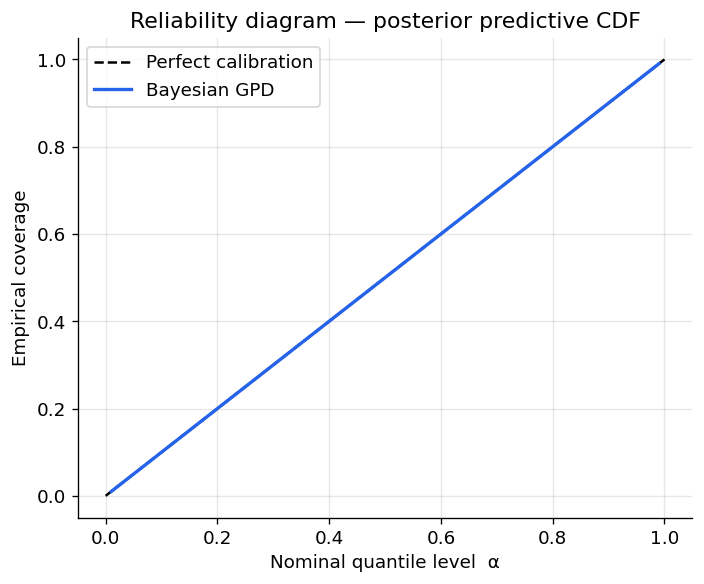

In [ ]:
# ── Plot 6: Reliability diagram  (probability calibration plot) ───────────────
# For each run collect the posterior predictive CDF evaluated at the true quantile.
# A perfectly calibrated model should satisfy P(X' <= x_p) = p.

# We reuse the demo trace for illustration.
alpha_levels = np.linspace(0.01, 0.99, 50)
true_val_demo = true_quantile(0.99, XI_TRUE, SIGMA_TRUE)

pp_cdf_at_alpha = []
for alpha in alpha_levels:
    q_alpha = np.quantile(pp_samples, alpha)
    # fraction of times the true 0.99-quantile exceeds q_alpha:
    # → this is checking the whole predictive CDF
    pp_cdf_at_alpha.append(np.mean(pp_samples <= q_alpha))

# Standard reliability diagram: nominal vs empirical
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax.plot(alpha_levels, pp_cdf_at_alpha, color=COLORS[0], lw=2, label='Bayesian GPD')
ax.set_xlabel('Nominal quantile level  α')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability diagram — posterior predictive CDF')
ax.legend()
plt.tight_layout()
plt.show()

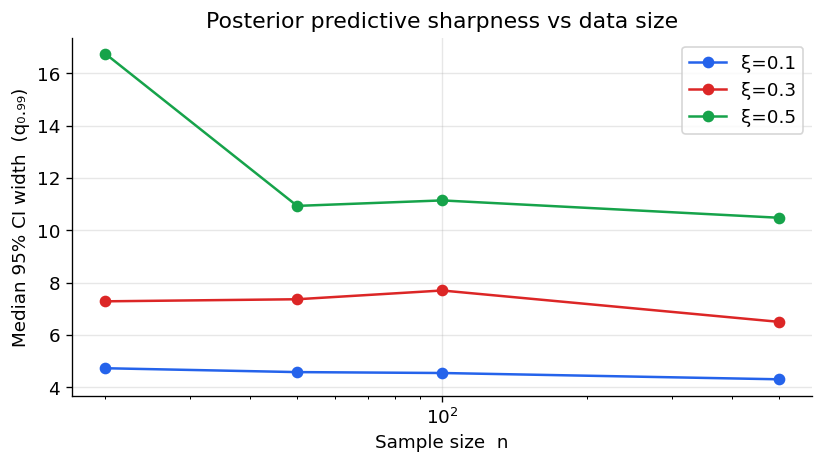

In [ ]:
# ── Plot 7: Posterior predictive interval width vs n ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for i, xi in enumerate(XI_VALUES):
    sub = df[df['xi_true'] == xi].groupby('n')['q_width_95'].median()
    ax.plot(sub.index, sub.values, 'o-', color=COLORS[i], label=f'ξ={xi}')
ax.set_xscale('log')
ax.set_xlabel('Sample size  n')
ax.set_ylabel('Median 95% CI width  (q₀.₉₉)')
ax.set_title('Posterior predictive sharpness vs data size')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Computational cost

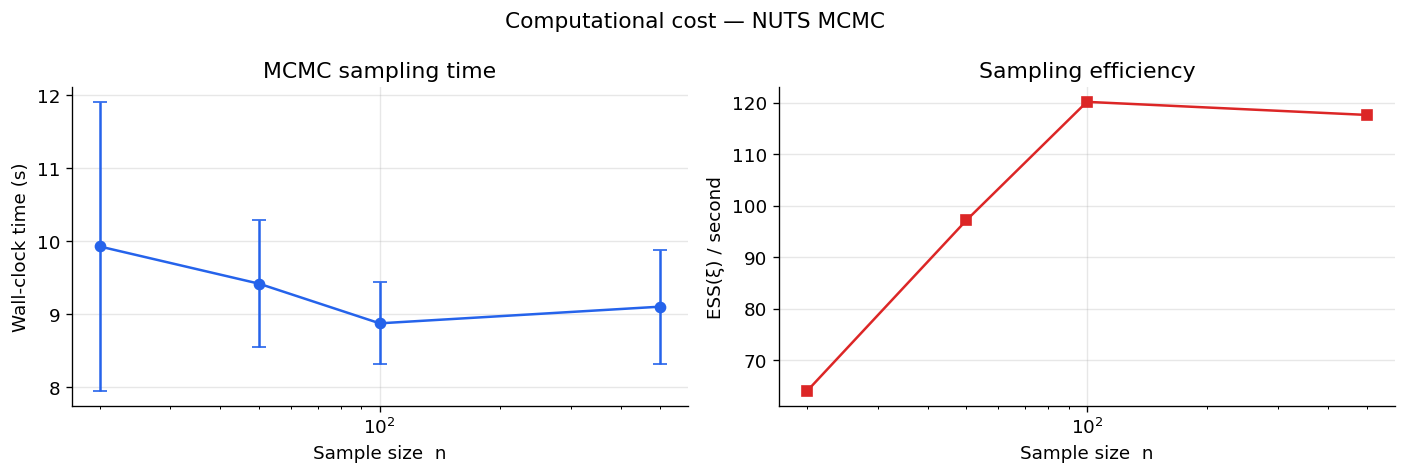

R-hat diagnostics (should be < 1.01 for convergence):
     rhat_xi  rhat_sigma
n                       
20    1.0053      1.0051
50    1.0018      1.0021
100   1.0018      1.0016
500   1.0016      1.0017


In [ ]:
# ── Plot 8: Sampling time vs n ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

runtime_agg = df.groupby('n')['runtime_s'].agg(['mean', 'std']).reset_index()

axes[0].errorbar(runtime_agg['n'], runtime_agg['mean'],
                 yerr=runtime_agg['std'], fmt='o-', color=COLORS[0], capsize=4)
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample size  n')
axes[0].set_ylabel('Wall-clock time (s)')
axes[0].set_title('MCMC sampling time')

# ESS / sec as a quality-per-unit-time metric
df['ess_per_sec'] = df['ess_xi'] / df['runtime_s']
ess_agg = df.groupby('n')['ess_per_sec'].median()
axes[1].plot(ess_agg.index, ess_agg.values, 's-', color=COLORS[1])
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample size  n')
axes[1].set_ylabel('ESS(ξ) / second')
axes[1].set_title('Sampling efficiency')

plt.suptitle('Computational cost — NUTS MCMC', fontsize=13)
plt.tight_layout()
plt.show()

print('R-hat diagnostics (should be < 1.01 for convergence):')
print(df.groupby('n')[['rhat_xi', 'rhat_sigma']].mean().round(4))

## 9. Return-level analysis

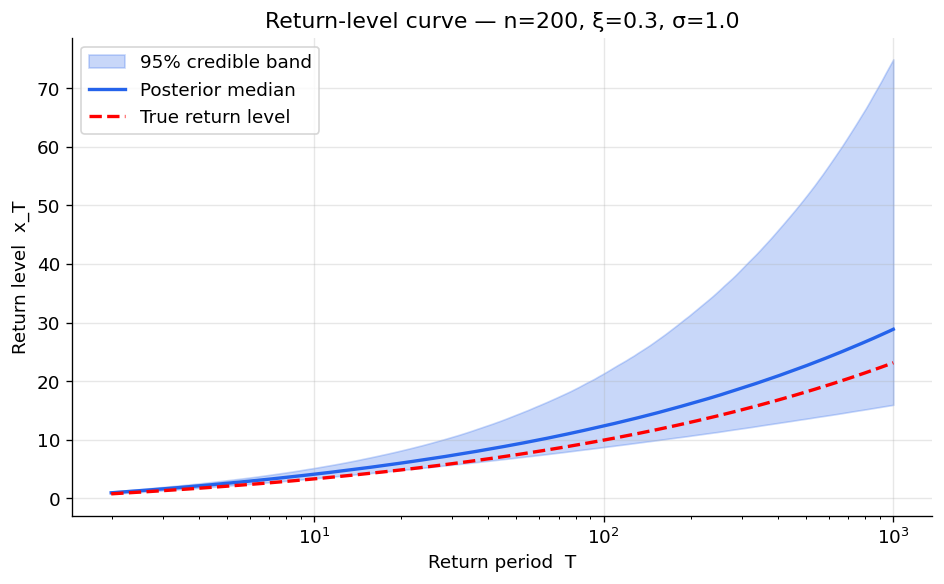

In [ ]:
# ── Return-level curve with credible band ─────────────────────────────────────
# Use the demo trace (n=200, xi=0.3, sigma=1.0)

xi_s_demo    = trace_demo.posterior['xi'].values.flatten()
sigma_s_demo = trace_demo.posterior['sigma'].values.flatten()

T_grid = np.logspace(0.3, 3, 200)   # return periods 2 to 1000

# For each T, compute return level for every posterior sample
rl_matrix = np.array([return_level(xi_s_demo, sigma_s_demo, T) for T in T_grid])  # (T, samples)
rl_true_curve = return_level(np.array([XI_TRUE]), np.array([SIGMA_TRUE]), T_grid).flatten()

rl_med  = np.median(rl_matrix, axis=1)
rl_lo   = np.quantile(rl_matrix, 0.025, axis=1)
rl_hi   = np.quantile(rl_matrix, 0.975, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(T_grid, rl_lo, rl_hi, alpha=0.25, color=COLORS[0], label='95% credible band')
ax.plot(T_grid, rl_med,        color=COLORS[0], lw=2, label='Posterior median')
ax.plot(T_grid, rl_true_curve, color='red',      lw=2, ls='--', label='True return level')
ax.set_xscale('log')
ax.set_xlabel('Return period  T')
ax.set_ylabel('Return level  x_T')
ax.set_title(f'Return-level curve — n={N_DEMO}, ξ={XI_TRUE}, σ={SIGMA_TRUE}')
ax.legend()
plt.tight_layout()
plt.show()

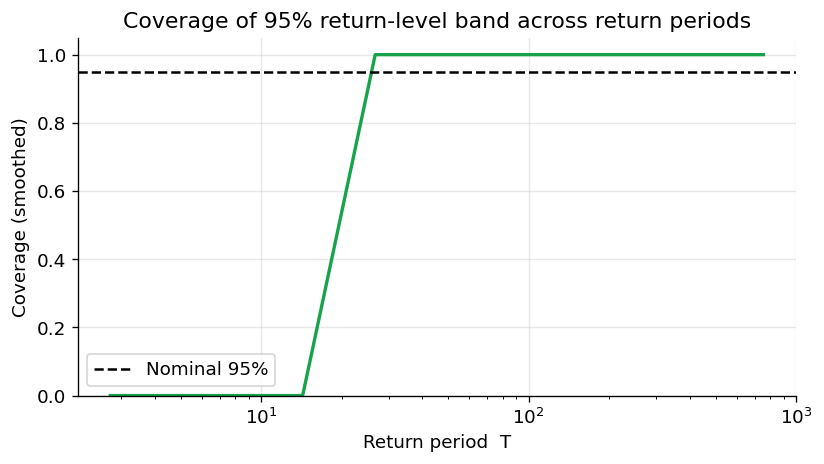

In [ ]:
# ── Return-level coverage vs T ────────────────────────────────────────────────
# Check whether the 95% band covers the true value at each return period

cov_at_T = []
for i, T in enumerate(T_grid):
    covered = (rl_lo[i] <= rl_true_curve[i] <= rl_hi[i])
    cov_at_T.append(float(covered))

# Smooth over T (window = 10)
from numpy.lib.stride_tricks import sliding_window_view
cov_smooth = np.mean(sliding_window_view(np.array(cov_at_T), 20), axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T_grid[10:-9], cov_smooth, color=COLORS[2], lw=2)
ax.axhline(0.95, ls='--', color='black', lw=1.5, label='Nominal 95%')
ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.set_xlabel('Return period  T')
ax.set_ylabel('Coverage (smoothed)')
ax.set_title('Coverage of 95% return-level band across return periods')
ax.legend()
plt.tight_layout()
plt.show()

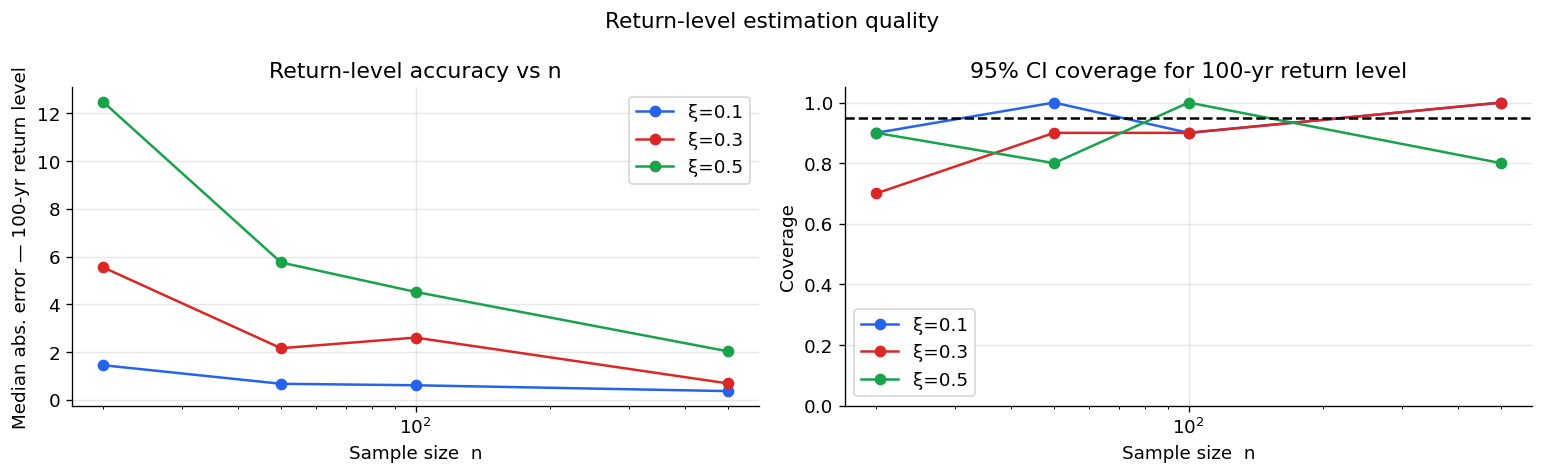

In [ ]:
# ── Plot 9: Return-level error across n and ξ ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, xi in enumerate(XI_VALUES):
    sub = df[df['xi_true'] == xi].groupby('n')['rl_abs_error'].median()
    axes[0].plot(sub.index, sub.values, 'o-', color=COLORS[i], label=f'ξ={xi}')

axes[0].set_xscale('log')
axes[0].set_xlabel('Sample size  n')
axes[0].set_ylabel('Median abs. error — 100-yr return level')
axes[0].set_title('Return-level accuracy vs n')
axes[0].legend()

rl_cov = df.groupby(['n', 'xi_true'])['rl_covered_95'].mean().reset_index()
for i, xi in enumerate(XI_VALUES):
    sub = rl_cov[rl_cov['xi_true'] == xi]
    axes[1].plot(sub['n'], sub['rl_covered_95'], 'o-', color=COLORS[i], label=f'ξ={xi}')
axes[1].axhline(0.95, ls='--', color='black', lw=1.5)
axes[1].set_xscale('log')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Sample size  n')
axes[1].set_ylabel('Coverage')
axes[1].set_title('95% CI coverage for 100-yr return level')
axes[1].legend()

plt.suptitle('Return-level estimation quality', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Summary table & proposed extensions

### 10.1 Final summary

In [ ]:
summary_table = agg[[
    'n', 'xi_true',
    'xi_bias_mean', 'xi_rmse_mean',
    'q_rel_error_med',
    'coverage_95', 'coverage_50',
    'width_95_med', 'runtime_mean'
]].copy()

summary_table.columns = [
    'n', 'ξ_true',
    'ξ bias', 'ξ RMSE',
    'Rel. q error',
    'Cov. 95%', 'Cov. 50%',
    'CI width (95%)', 'Time (s)'
]

print(summary_table.to_string(index=False))

  n  ξ_true  ξ bias  ξ RMSE  Rel. q error  Cov. 95%  Cov. 50%  CI width (95%)  Time (s)
 20  0.1000 -0.2533  0.3788        0.2969    0.3000    0.0000          4.7341   10.9709
 20  0.3000 -0.0656  0.5429        0.5509    0.4000    0.0000          7.2885    9.7679
 20  0.5000 -0.1086  0.5348        1.1370    0.4000    0.0000         16.7355    9.0347
 50  0.1000 -0.0231  0.2256        0.0629    0.0000    0.0000          4.5864    9.5557
 50  0.3000  0.0086  0.2465        0.2800    0.2000    0.0000          7.3677    9.5578
 50  0.5000 -0.1189  0.3270        0.4689    0.0000    0.0000         10.9318    9.1300
100  0.1000 -0.0099  0.1477        0.1663    0.0000    0.0000          4.5520    8.8561
100  0.3000  0.0649  0.2091        0.2931    0.2000    0.0000          7.7020    9.0144
100  0.5000  0.0096  0.2082        0.2466    0.1000    0.0000         11.1411    8.7453
500  0.1000 -0.0336  0.0629        0.0471    0.0000    0.0000          4.3118    9.1480
500  0.3000 -0.0148  0.0654     

### 10.2 Proposed extensions

The following directions would naturally complement this Bayesian baseline before or during comparison with the possibilistic framework.

---

**A — Threshold selection sensitivity**  
All GPD inference conditions on a threshold $u$. The current setup assumes $u$ is known. A proper baseline should vary $u$ (e.g. via mean excess plots or the Northrop & Coleman (2014) threshold diagnostic) and propagate threshold uncertainty into the posterior predictive.

**B — Profile likelihood comparison**  
Overlay the MLE + profile likelihood confidence intervals on the same plots. This gives a direct frequentist reference and makes the Bayesian shrinkage from the C&C prior visible.

**C — Model misspecification**  
Simulate data from a heavy-tailed distribution that is *not* exactly GPD (e.g. Student-t exceedances, or a mixture). Measure how quickly the Bayesian credible intervals deteriorate, and compare with the possibilistic model which is designed to be more robust to prior mis-specification.

**D — Probabilistic dilution experiment**  
The key motivation for possibility theory is *probabilistic dilution*: as epistemic uncertainty grows, Bayesian predictions of extreme events can decrease. Replicate this by reducing $n$ and measuring whether $\bar{\mathbb{P}}(X' > x_p)$ increases (possibilistic) or decreases (Bayesian) as $n \to 0$.

**E — Proper scoring rules**  
Evaluate the full predictive distribution with the *continuous ranked probability score* (CRPS) and the *energy score*, not just quantile accuracy. These are more sensitive to calibration in the tails.

**F — Laplace / variational approximation**  
MCMC is slow. Implement a Laplace approximation around the MAP estimate (using the observed Fisher information as the covariance) and compare accuracy vs speed. This is the same quantity the possibilistic BvM theorem converges to.

**G — Real flood data**  
Apply to Singapore PUB discharge records or ERA5 precipitation extremes. The `lmoments3` package fits GPD via L-moments for a quick sanity check against the Bayesian posterior.